**Task 2: Machine Learning Regression Pipeline**

This notebook implements the complete machine learning workflow for predicting taxi fare amounts, including preprocessing, feature engineering, model training, hyperparameter tuning, and pipeline creation.

In [1]:
import seaborn as sns 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

**1. Load Dataset**

In [3]:
mydata=pd.read_csv('cleaned_rides.csv')

In [5]:
mydata.head(10)

,Car Condition,Weather,Traffic Condition,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,Very Good,windy,Congested Traffic,4.5,2009-06-15 17:26:21,-73.844311,40.721319,-73.841610,40.712278,1,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-167.240469
1,Excellent,cloudy,Flow Traffic,16.9,2010-01-05 16:52:16,-74.016048,40.711303,-73.979268,40.782004,1,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-21.498366
2,Bad,stormy,Congested Traffic,5.7,2011-08-18 00:35:00,-73.982738,40.761270,-73.991242,40.750562,2,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,148.966789
3,Very Good,stormy,Flow Traffic,7.7,2012-04-21 04:30:42,-73.987130,40.733143,-73.991567,40.758092,1,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,7.672164
4,Bad,stormy,Congested Traffic,5.3,2010-03-09 07:51:00,-73.968095,40.768008,-73.956655,40.783762,1,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-28.802783
5,Excellent,sunny,Congested Traffic,12.1,2011-01-06 09:50:45,-74.000964,40.731630,-73.972892,40.758233,1,...,1,3,2011,42.335622,32.824930,20.648176,15.741133,7.649541,3.787239,-38.631713
6,Excellent,windy,Flow Traffic,7.5,2012-11-20 20:35:00,-73.980002,40.751662,-73.973802,40.764842,1,...,11,1,2012,42.563234,35.482608,18.113693,19.126670,10.993150,1.555807,-19.610063
7,Good,sunny,Congested Traffic,16.5,2012-01-04 17:22:00,-73.951300,40.774138,-73.990095,40.751048,1,...,1,2,2012,42.533214,36.829343,16.949505,20.548489,12.449213,4.155444,128.147501
8,Excellent,rainy,Dense Traffic,9.0,2012-12-03 13:10:00,-74.006462,40.726713,-73.993078,40.731628,1,...,12,0,2012,42.240568,29.608237,23.942272,11.667601,3.637447,1.253232,-64.140893
9,Very Good,sunny,Dense Traffic,8.9,2009-09-02 01:11:00,-73.980658,40.733873,-73.991540,40.758138,2,...,9,2,2009,42.218767,33.106804,20.538553,16.193381,8.129651,2.849627,18.762242


**2. Missing Values Check**

In [6]:
mydata.isna().sum()

Car Condition        0
Weather              0
Traffic Condition    0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             0
ewr_dist             0
lga_dist             0
sol_dist             0
nyc_dist             0
distance             0
bearing              0
dtype: int64

**3. Duplicate Check**

In [7]:
mydata.duplicated().sum()

np.int64(0)

**4. Encoding**

In [49]:
mydata['Car Condition'].value_counts()

Car Condition
Very Good    122520
Bad          122315
Good         122306
Excellent    122063
Name: count, dtype: int64

In [18]:
from sklearn.preprocessing import OrdinalEncoder
encoder=OrdinalEncoder(categories=[['Bad','Good','Very Good','Excellent']])
mydata[['Car Condition']]=encoder.fit_transform(mydata[['Car Condition']])


In [9]:
mydata.head()

,Car Condition,Weather,Traffic Condition,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,2.0,windy,Congested Traffic,4.5,2009-06-15 17:26:21,-73.844311,40.721319,-73.841610,40.712278,1,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-167.240469
1,3.0,cloudy,Flow Traffic,16.9,2010-01-05 16:52:16,-74.016048,40.711303,-73.979268,40.782004,1,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-21.498366
2,0.0,stormy,Congested Traffic,5.7,2011-08-18 00:35:00,-73.982738,40.761270,-73.991242,40.750562,2,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,148.966789
3,2.0,stormy,Flow Traffic,7.7,2012-04-21 04:30:42,-73.987130,40.733143,-73.991567,40.758092,1,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,7.672164
4,0.0,stormy,Congested Traffic,5.3,2010-03-09 07:51:00,-73.968095,40.768008,-73.956655,40.783762,1,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-28.802783


In [10]:
mydata['Weather'].value_counts()

Weather
sunny     98236
rainy     97888
cloudy    97834
stormy    97813
windy     97433
Name: count, dtype: int64

In [51]:
mydata['Traffic Condition'].value_counts()

Traffic Condition
Congested Traffic    163297
Flow Traffic         162964
Dense Traffic        162943
Name: count, dtype: int64

In [19]:
from sklearn.preprocessing import OneHotEncoder
hot_encoder =OneHotEncoder(drop='first',sparse_output=False)
encoded=hot_encoder.fit_transform(mydata[['Weather','Traffic Condition']])
encoded_columns=hot_encoder.get_feature_names_out(['Weather','Traffic Condition'])
encodeed_df=pd.DataFrame(encoded,columns=encoded_columns,index=mydata.index)
mydata.drop(columns=['Weather','Traffic Condition'],inplace=True)
mydata=pd.concat([mydata,encodeed_df],axis=1)

**Why?**

Ordinal Encoding was used for Car Condition because it has a natural order, while One-Hot Encoding was used for Weather and Traffic Condition because they are nominal categorical variables.

**5. Feature Selection**

In [ ]:
corr = mydata.corr(numeric_only=True)
target_corr = corr['fare_amount'].sort_values(ascending=False)
target_corr

In [ ]:
# Drop features that are very weakly correlated with the target (weak predictors)
low_corr_threshold = 0.02
low_corr_features = target_corr[abs(target_corr) < low_corr_threshold].index.tolist()
low_corr_features = [c for c in low_corr_features if c != 'fare_amount']
print("Weak predictors (|corr| with target < 0.02):", low_corr_features)

In [ ]:
# Check multicollinearity between predictor features (not the target)
feature_corr = mydata.drop(columns=['fare_amount']).corr(numeric_only=True)

high_corr_pairs = []
cols = feature_corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c = feature_corr.iloc[i, j]
        if abs(c) > 0.9:
            high_corr_pairs.append((cols[i], cols[j], round(c, 3)))

print("Highly correlated feature pairs (|corr| > 0.9):", high_corr_pairs)
# keep the first feature of each pair, drop the second to remove redundancy
redundant_features = [pair[1] for pair in high_corr_pairs]

In [ ]:
features_to_drop = list(set(
    ['fare_amount', 'pickup_datetime', 'day', 'weekday'] + low_corr_features + redundant_features
))
print("Final list of dropped features:", features_to_drop)

x = mydata.drop(columns=features_to_drop)
y = mydata['fare_amount']

**Why?**

The datetime column was removed because temporal features (hour, month, and year) had already been extracted. `day` and `weekday` were removed as a fixed decision (redundant with the extracted temporal features). Beyond that, feature selection is now driven by two checks instead of eyeballing the correlation table: (1) features whose correlation with `fare_amount` is below 0.02 are dropped as weak predictors, and (2) for any pair of predictor features correlated above 0.9 with each other (multicollinearity), only one is kept.

**6. Train-Test Split**

In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

**7. Feature Scaling**

In [22]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

StandardScaler was applied after the train-test split to avoid data leakage and because Linear Regression is sensitive to feature scales.

**8. Baseline Model (Linear Regression)**

In [23]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_pred_reg=model.predict(x_test_scaled)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_reg)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 2.257631333238135
MSE : 20.124781197594565
RMSE: 4.486065224402624
R²  : 0.7817757654207081


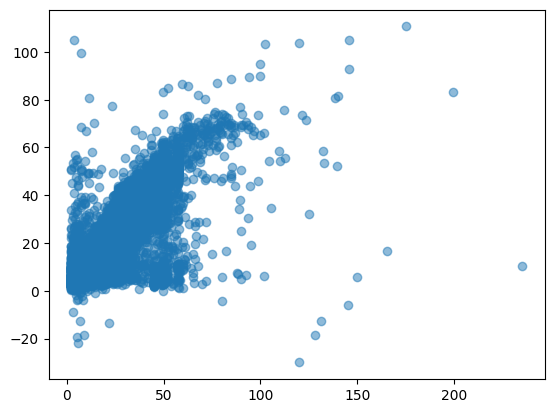

In [64]:
plt.scatter(y_test, y_pred_reg, alpha=0.5)

In [26]:
linear_results = pd.DataFrame({
    'Model': ['Linear Regression'],
    'MAE': [mae],
    'MSE': [mse],
    'RMSE': [rmse],
    'R2 Score': [r2]
})

linear_results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,2.257631,20.124781,4.486065,0.781776


**9. Cross Validation**

In [27]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    x_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("R² Scores:", cv_scores)
print("Average R²:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

R² Scores: [0.75643468 0.77145009 0.769451   0.73116761 0.74532356]
Average R²: 0.7547653897541323
Standard Deviation: 0.015118442195263593


The baseline Linear Regression model achieved an average cross-validation R² score of approximately 0.755 with low variance, indicating stable performance across different folds.

**10. Hyperparameter Tuning (Random Forest)**

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

X_train_tune = x_train.sample(frac=0.1, random_state=42)
y_train_tune = y_train.loc[X_train_tune.index]

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train_tune, y_train_tune)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, None], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score 

In [34]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
0.838996151896132


The tuned Random Forest outperformed the baseline Linear Regression by reducing prediction error and increasing the R² score.

In [36]:
best_rf = RandomForestRegressor(
    **grid_search.best_params_,
    random_state=42
)

best_rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [37]:
y_pred_rf = best_rf.predict(x_test)

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

MAE : 1.712069202140786
MSE : 13.788425675347733
RMSE: 3.713276945683924
R²  : 0.850484404798604


In [39]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Tuned Random Forest"],
    "MAE": [mae, mae_rf],
    "MSE": [mse, mse_rf],
    "RMSE": [rmse, rmse_rf],
    "R² Score": [r2, r2_rf]
})

comparison

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,2.257631,20.124781,4.486065,0.781776
1,Tuned Random Forest,1.712069,13.788426,3.713277,0.850484


The tuned Random Forest outperformed the baseline Linear Regression by reducing prediction error and increasing the R² score.

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import joblib


In [ ]:
# Only scale genuinely numeric features. One-hot (0/1) and ordinal-encoded
# columns are already on a meaningful scale, so we pass them through unchanged
# instead of standardizing them.
categorical_encoded_features = [c for c in (['Car Condition'] + list(encoded_columns)) if c in x_train.columns]
numeric_features = [c for c in x_train.columns if c not in categorical_encoded_features]

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'
)

**Why?**

`StandardScaler` is applied only to the raw numeric columns. The One-Hot encoded columns (`Weather_*`, `Traffic Condition_*`) and the Ordinal-encoded `Car Condition` column are passed through unchanged via `remainder='passthrough'`, since scaling already-binary/ordinal-coded columns adds noise without any benefit.

In [42]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_rf)
])

In [43]:
pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse 

In [46]:
pipeline_pred = pipeline.predict(x_test)

In [47]:
from sklearn.metrics import r2_score

print("Pipeline R²:", r2_score(y_test, pipeline_pred))

Pipeline R²: 0.8502107676180732


In [48]:
joblib.dump(pipeline, "final_pipeline.joblib")

['final_pipeline.joblib']

In [50]:
loaded_pipeline = joblib.load("final_pipeline.joblib")

loaded_pipeline.predict(x_test.head())

array([10.66437302,  7.25551984,  7.81993849,  4.77859921,  8.98666508])

The Pipeline combines preprocessing and model training into one reusable workflow, ensuring that the same transformations are consistently applied during both training and prediction.

What I would try next

Future improvements could include:

- Trying Gradient Boosting or XGBoost.
- Performing additional feature engineering.
- Exploring Target Encoding for high-cardinality categorical variables.
- Using a larger hyperparameter search space for Random Forest.